# Advanced Certification Programme in Agentic and Generative AI
## A Programme by IISc and TalentSprint
### Mini-Project 1 Part-A: Spam Classification

**(Solution)**

**DISCLAIMER:** THIS NOTEBOOK IS PROVIDED ONLY AS A REFERENCE SOLUTION NOTEBOOK FOR THE MINI-PROJECT. THERE MAY BE OTHER POSSIBLE APPROACHES/METHODS TO ACHIEVE THE SAME RESULTS.

## Learning Objectives

At the end of the mini-project, you will be able to :

* understand how to successfully generate code using LLMs

* following sections will help you understand the various steps required for text classification:
  * Create text vectorization layer
  * Create embeddings of words in the message
  * Visualize the different categories of words
  * Build a model to classify the messages as Spam or Ham
  * Get the evaluation score of the model

## Problem Statement

Email and messaging platforms receive a large volume of messages daily, many of which are unsolicited or malicious spam. Identifying and filtering such messages is important to protect users from phishing attempts, scams, and unwanted advertisements. Traditional rule-based approaches often struggle to adapt to evolving spam patterns.

In this project, the objective is to develop a **Spam/Ham (Not Spam) classification system** that can automatically determine whether a given message is spam or legitimate. The system should leverage **Generative AI capabilities to generate the necessary code and logic** required for building the classification pipeline.

You will interact with an LLM to **design prompts that generate code for tasks such as data loading, preprocessing, model training, and evaluation.** The generated code will then be executed to build a working text classification model. Through this process, you will explore how LLMs can assist in both **problem solving and automated code generation** for machine learning workflows.

The final solution should be able to take a text message as input and classify it as **Spam** or **Ham**, demonstrating the integration of **prompt engineering, code generation, and machine learning-based text classification**.

## Dataset

The [SMS Spam Collection dataset](https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset) is a set of SMS tagged messages that have been collected for SMS Spam research. It contains one set of SMS messages in English of 5,574 messages, tagged acording being ham (legitimate) or spam.


## Instructions

* Use the SMS Spam collection dataset
* Based on your understanding of steps required to do text classification from previous assignments, generate the code using LLM to accomplish the task
* There is no restriction on the number of prompts or choice of LLM
* Do not use a pretrained model
* Use any LLM to pass prompts and generate code from it
* All the sections are to be solved by making use of prompts
* Feel free to add/delete code cells as you may require
* Use any number of code cells/prompts to solve any particular section

## Parameters of evaluations

* Accuracy on Test data set
* Choice of preprocessing steps
* Model Architecture
* Design parameters choice
* Number of experiments conducted
* Parameter tuning
* Visualizations
  * Train validation loss & other metrics
  * Word clouds of words in each category
  * Embeddings visualizations


## **HINT**

Please take hints from the Additional Notebook released in Module 2, **Additional_NB_02_TextVectorization_and_Embedding_Layers**

## Grading = 4 Points

In [ ]:
# prompt: Create a hidden code cell with @#title Download the Dataset. Data should be downloaded from the following link: https://cdn.exec.talentsprint.com/static/aimlops/c3/spam.csv

#@title Download the Dataset
!wget https://cdn.exec.talentsprint.com/static/aimlops/c3/spam.csv


--2026-03-09 10:25:37--  https://cdn.exec.talentsprint.com/static/aimlops/c3/spam.csv
Resolving cdn.exec.talentsprint.com (cdn.exec.talentsprint.com)... 172.105.52.210
Connecting to cdn.exec.talentsprint.com (cdn.exec.talentsprint.com)|172.105.52.210|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 503663 (492K) [application/octet-stream]
Saving to: ‘spam.csv’

spam.csv            100%[===================>] 491.86K   642KB/s    in 0.8s    

2026-03-09 10:25:39 (642 KB/s) - ‘spam.csv’ saved [503663/503663]



### Import Neccesary Packages

In [ ]:
# Initial Packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import string
from sklearn.decomposition import PCA

### Understand the Use of Gemini with Colab

Explore how to integrate and use the Gemini model present within Google Colab for generating code, explanations, and solutions during the project.

This involves interacting with Gemini through prompts to assist in tasks such as writing code, debugging, and guiding the implementation of the spam classification pipeline.

1. Click on '**generate**'

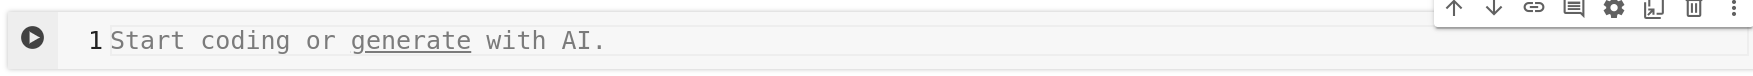

2. Enter the prompt

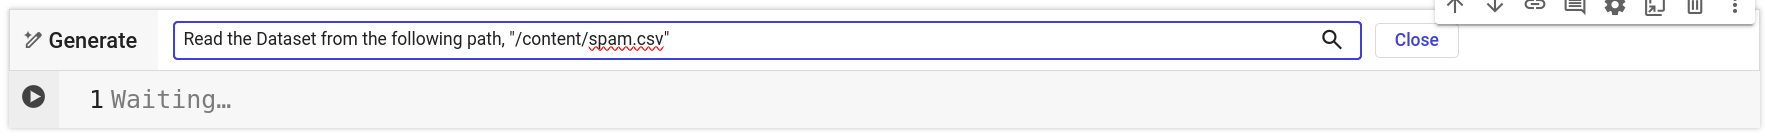

3. Output

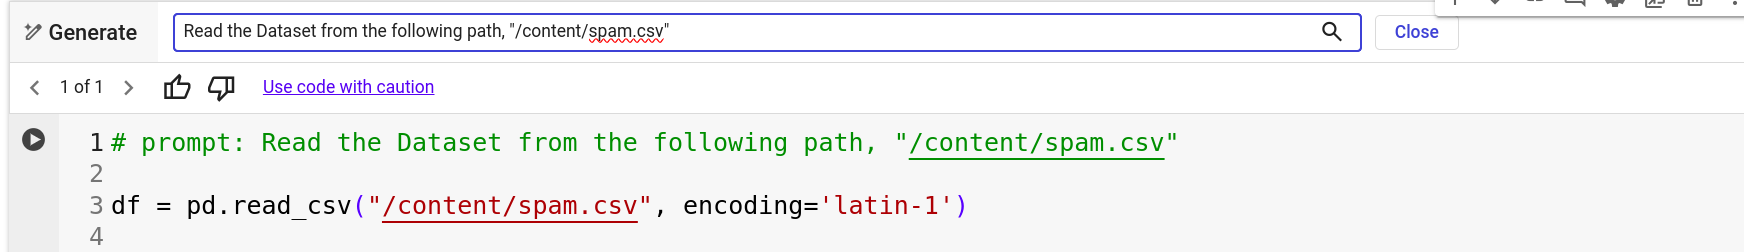

Additionally, an example code can be executed in the cell to give LLM a better understanding of the kind of code we want it to generate.

### Read the Data

In [ ]:
# prompt: Read the Dataset from the following path, "/content/spam.csv"

df = pd.read_csv("/content/spam.csv", encoding='latin-1')


In [ ]:
# prompt: Display the head section of the dataset. Display top 7 records.

df.head(7)


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN
5,spam,FreeMsg Hey there darling it's been 3 week's n...,NaN,NaN,NaN
6,ham,Even my brother is not like to speak with me. ...,NaN,NaN,NaN


In [ ]:
# prompt: Give a description of the dataset. Number of features. Check the number of unique values in the features. Put the entire code in the function and call it.

def describe_dataset():
  """
  This function provides a description of the dataset, including the number of features,
  and the number of unique values in each feature.
  """
  print("Dataset Description:")
  print(f"Number of features: {df.shape[1]}")
  print("\nUnique values in each feature:")
  for col in df.columns:
    print(f"{col}: {df[col].nunique()}")

describe_dataset()

Dataset Description:
Number of features: 5

Unique values in each feature:
v1: 2
v2: 5169
Unnamed: 2: 43
Unnamed: 3: 10
Unnamed: 4: 5


In [ ]:
# prompt: Create the final dataset by only considering features v1 and v2. Name the dataframe as 'df'.

df = df[['v1', 'v2']]

In [ ]:
# prompt: Display the first 7 records of the updated dataframe.

df.head(7)

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
5,spam,FreeMsg Hey there darling it's been 3 week's n...
6,ham,Even my brother is not like to speak with me. ...


In [ ]:
# prompt: Create a new variable labels by taking the 'v1' feature from the dataframe and values variable from the 'v2' feature of the dataframe.

labels = df['v1']
values = df['v2']

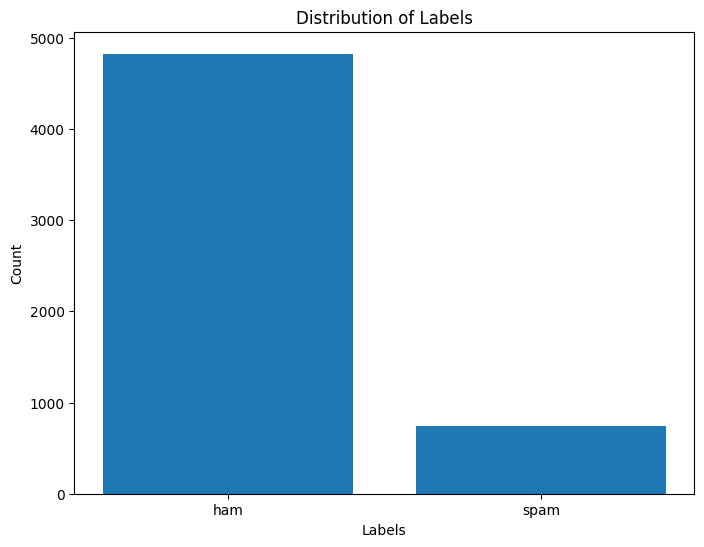

In [ ]:
# prompt: Visualize labels by making use of appropriate plots.

# Count the occurrences of each label
label_counts = labels.value_counts()

# Create a bar plot
plt.figure(figsize=(8, 6))
plt.bar(label_counts.index, label_counts.values)
plt.xlabel("Labels")
plt.ylabel("Count")
plt.title("Distribution of Labels")
plt.show()

In [ ]:
# prompt: encode the categorical variable and replace in the dataframe. Map as follows, {'ham': 0, 'spam': 1}

# Create a mapping dictionary
mapping = {'ham': 0, 'spam': 1}

# Replace the values in the 'v1' column using the mapping
df['v1'] = df['v1'].map(mapping)

In [ ]:
# prompt: Display the first 7 records of the updated dataframe.

df.head(7)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,0,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,0,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,0,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,0,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN
5,1,FreeMsg Hey there darling it's been 3 week's n...,NaN,NaN,NaN
6,0,Even my brother is not like to speak with me. ...,NaN,NaN,NaN


### Data Preprocessing

In [ ]:
# prompt: Clean the text present in values. Create a function to do it and return the clean text. Update the dataframe with the cleaned text. Update the below code and also remove white spaces from the code.

import re

def clean_text(text):
  """
  This function cleans the text by removing punctuation, converting to lowercase,
  and removing extra whitespace.
  """
  text = text.lower()  # Convert to lowercase
  text = re.sub(r'[^\w\s]', '', text)  # Remove punctuation
  text = " ".join(text.split())  # Remove extra whitespace
  return text

# Apply the clean_text function to the 'v2' column
df['v2'] = df['v2'].apply(clean_text)


In [ ]:
# prompt: Display few records of df['v2']

print(df['v2'].head(10))

0    go until jurong point crazy available only in ...
1                              ok lar joking wif u oni
2    free entry in 2 a wkly comp to win fa cup fina...
3          u dun say so early hor u c already then say
4    nah i dont think he goes to usf he lives aroun...
5    freemsg hey there darling its been 3 weeks now...
6    even my brother is not like to speak with me t...
7    as per your request melle melle oru minnaminun...
8    winner as a valued network customer you have b...
9    had your mobile 11 months or more u r entitled...
Name: v2, dtype: object


* Text cleaning standardizes the text data, removing noise.
* Tokenization converts text to numerical representations for model input.
* Padding ensures all sequences have the same length, required for many ML models.

In [ ]:
# prompt: Split the dataframe into training and testing sets.

from sklearn.model_selection import train_test_split

# Split the dataframe into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(df['v2'], df['v1'], test_size=0.2, random_state=42)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((4457,), (1115,), (4457,), (1115,))

### Apply the Vectorization

In [ ]:
# prompt: Create TextVectorization layer and adapt to the dataset.

from tensorflow.keras.layers import TextVectorization

# Create TextVectorization layer
vectorize_layer = TextVectorization(
    max_tokens=5000,
    output_mode='int',
    output_sequence_length=100
)

# Adapt the layer to the training data
vectorize_layer.adapt(X_train)

In [ ]:
# prompt: Visualize and compare one sentence from the raw data and vectorized data.

# Get one sentence from the raw data
raw_sentence = df['v2'][0]

# Vectorize the sentence
vectorized_sentence = vectorize_layer([raw_sentence])

# Print the raw sentence
print("Raw sentence:", raw_sentence)

# Print the vectorized sentence
print("Vectorized sentence:", vectorized_sentence)


Raw sentence: go until jurong point crazy available only in bugis n great world la e buffet cine there got amore wat
Vectorized sentence: tf.Tensor(
[[  45  538    1  902  743  662   65    9 1331   92  133  336 1126  170
  3473 1525   70   57    1  150    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0]], shape=(1, 100), dtype=int64)


In [ ]:
# prompt: Vector representation of the word 'movie'

# USING TENSORFLOW
word = 'movie'
word_vector = vectorize_layer([word])[0]
print(word_vector)

tf.Tensor(
[577   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0], shape=(100,), dtype=int64)


### Design the Model

In [ ]:
# prompt: Design a Pytorch based neural network model to train on the data. Add a vectorization layer and embedding layer.

import torch
import torch.nn as nn

class SpamClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim):
        super(SpamClassifier, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True) #
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, text):
        embedded = self.embedding(text)
        output, (hidden, cell) = self.lstm(embedded)
        final_output = self.fc(hidden[-1, :, :])
        return final_output

# Define model parameters
vocab_size = 5000  # Adjust based on your vectorization layer
embedding_dim = 128
hidden_dim = 256
output_dim = 1  # Binary classification (spam or ham)

# Create the model
model = SpamClassifier(vocab_size, embedding_dim, hidden_dim, output_dim)

# Example usage
# Assuming 'X_train' is your input data and 'y_train' are the labels
# Convert data to PyTorch tensors
X_train_tensor = torch.tensor(vectorize_layer(X_train).numpy(), dtype=torch.long)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32)

### Extract the Embeddings before Training

In [ ]:
# prompt: Extract the Embeddings before Training from 'SpamClassifier'

# Get the embeddings
embeddings = model.embedding.weight.detach().numpy()
print(f"Embeddings shape: {embeddings.shape}")

Embeddings shape: (5000, 128)


In [ ]:
# prompt: Get the vocabulary from the TextVectorization layer

# Get the vocabulary from the TextVectorization layer
vocabulary = vectorize_layer.get_vocabulary()
print(f"Vocabulary size: {len(vocabulary)}")


Vocabulary size: 5000


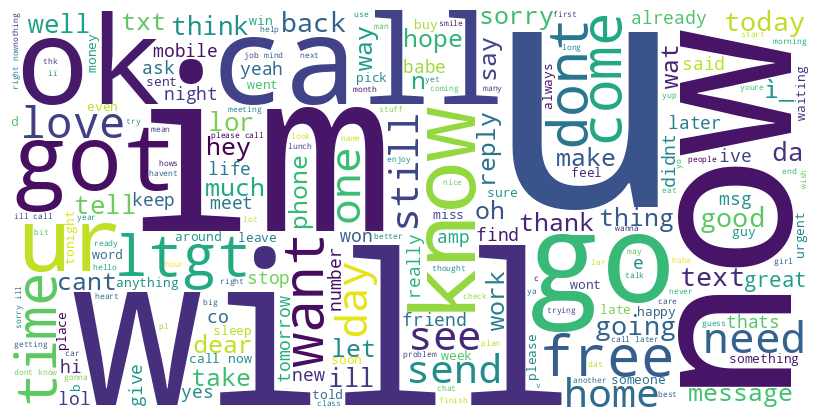

In [ ]:
# prompt: Plot a word cloud to identify most frequently occurring words from the vocabulary.

from wordcloud import WordCloud

# Combine all the text data into a single string
text_data = " ".join(df['v2'].tolist())

# Generate the word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text_data)

# Display the generated image:
plt.figure(figsize=(8, 8), facecolor=None)
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad=0)
plt.show()

In [ ]:
# prompt: Choose 10 most frequently occuring words from the word cloud and create a 2-dimensional PCA model of the word vectors using the scikit-learn PCA class.

from collections import Counter

# Get the word frequencies from the word cloud
word_counts = Counter(wordcloud.words_)

# Get the 10 most frequent words
top_words = [word for word, count in word_counts.most_common(10)]

# Get the word vectors for the top words
top_word_vectors = [embeddings[vectorize_layer([word])[0][0]] for word in top_words]

# Apply PCA to reduce the dimensionality to 2
pca = PCA(n_components=2)
reduced_vectors = pca.fit_transform(top_word_vectors)

# Print the reduced vectors
print(reduced_vectors)

[[ 1.86361262  3.10788018]
 [ 1.59744401  1.22858899]
 [ 5.21562455  8.81271083]
 [-1.83178904 -2.72764462]
 [ 2.26778467 -3.17679671]
 [-6.70264742 -2.40200693]
 [-6.23027914  4.29928223]
 [-5.30919125 -0.09748404]
 [ 4.13141661 -4.4572484 ]
 [ 4.99802441 -4.58728151]]


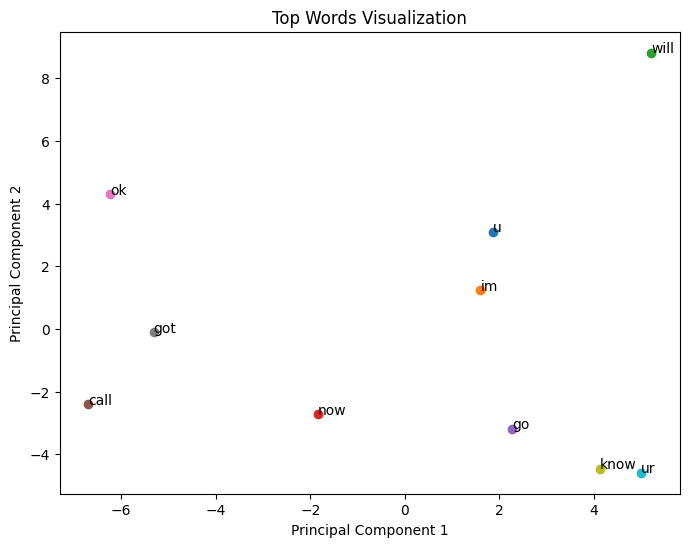

In [ ]:
# prompt: visualize top_words using an appropriate plot.

# Create a scatter plot
plt.figure(figsize=(8, 6))
for i, word in enumerate(top_words):
  x = reduced_vectors[i][0]
  y = reduced_vectors[i][1]
  plt.scatter(x, y)
  plt.annotate(word, (x, y))

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Top Words Visualization")
plt.show()


### Train the Model

In [ ]:
# prompt: Train the model on the data. Take hints from code in the cell and update it accordingly.

# Convert data to PyTorch tensors
X_train_tensor = torch.tensor(vectorize_layer(X_train).numpy(), dtype=torch.long)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32)
X_test_tensor = torch.tensor(vectorize_layer(X_test).numpy(), dtype=torch.long)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32)

# Define loss function and optimizer
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters())

# Training loop
num_epochs = 10
for epoch in range(num_epochs):
  # Forward pass
  outputs = model(X_train_tensor)
  loss = criterion(outputs.squeeze(), y_train_tensor)

  # Backward and optimize
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  # Print loss every few epochs
  if (epoch+1) % 2 == 0:
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

# Evaluation
with torch.no_grad():
  outputs = model(X_test_tensor)
  predicted = (torch.sigmoid(outputs.squeeze()) > 0.5).float()
  accuracy = (predicted == y_test_tensor).sum().item() / len(y_test_tensor)
  print(f'Test Accuracy: {accuracy:.4f}')


Epoch [2/10], Loss: 0.4863
Epoch [4/10], Loss: 0.3984
Epoch [6/10], Loss: 0.4250
Epoch [8/10], Loss: 0.4116
Epoch [10/10], Loss: 0.3976
Test Accuracy: 0.8637


### During Training collect the Loss and Metrics of training and validation sets, and plot the Metrics after training

Epoch [2/10], Train Loss: 0.3947, Val Loss: 0.3971, Train Accuracy: 0.8658, Val Accuracy: 0.8637
Epoch [4/10], Train Loss: 0.3947, Val Loss: 0.3971, Train Accuracy: 0.8658, Val Accuracy: 0.8637
Epoch [6/10], Train Loss: 0.3947, Val Loss: 0.3971, Train Accuracy: 0.8658, Val Accuracy: 0.8637
Epoch [8/10], Train Loss: 0.3947, Val Loss: 0.3971, Train Accuracy: 0.8658, Val Accuracy: 0.8637
Epoch [10/10], Train Loss: 0.3947, Val Loss: 0.3971, Train Accuracy: 0.8658, Val Accuracy: 0.8637


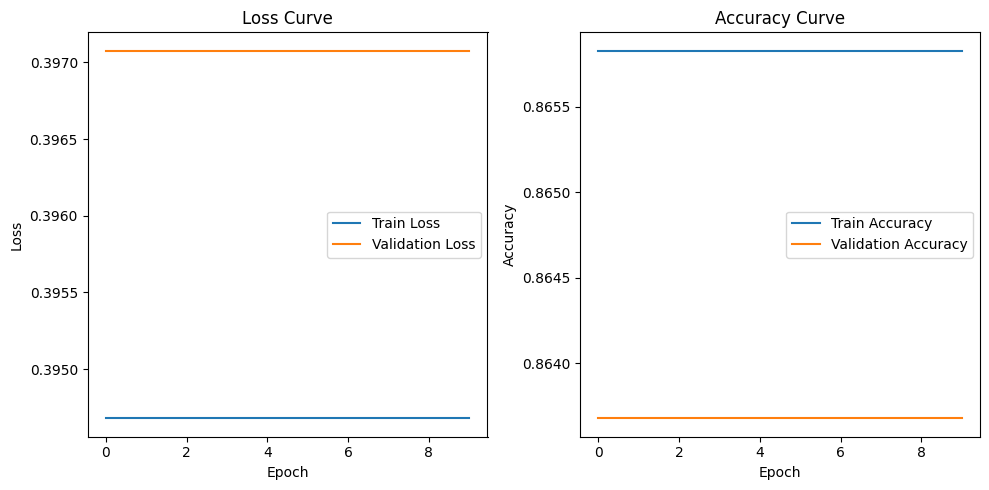

In [ ]:
# prompt: During Training Collect the loss and Metrics of Train and Validation. Plot the Metrics after Training.

# Convert data to PyTorch tensors
X_train_tensor = torch.tensor(vectorize_layer(X_train).numpy(), dtype=torch.long)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32)
X_test_tensor = torch.tensor(vectorize_layer(X_test).numpy(), dtype=torch.long)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32)

# Define loss function and optimizer
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model2.parameters())

# Training loop
num_epochs = 10
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(num_epochs):
  # Train
  model.train()
  outputs = model(X_train_tensor)
  train_loss = criterion(outputs.squeeze(), y_train_tensor)
  train_losses.append(train_loss.item())

  # Calculate accuracy
  predicted = (torch.sigmoid(outputs.squeeze()) > 0.5).float()
  train_accuracy = (predicted == y_train_tensor).sum().item() / len(y_train_tensor)
  train_accuracies.append(train_accuracy)

  # Validate
  model.eval()
  with torch.no_grad():
    outputs = model(X_test_tensor)
    val_loss = criterion(outputs.squeeze(), y_test_tensor)
    val_losses.append(val_loss.item())

    # Calculate accuracy
    predicted = (torch.sigmoid(outputs.squeeze()) > 0.5).float()
    val_accuracy = (predicted == y_test_tensor).sum().item() / len(y_test_tensor)
    val_accuracies.append(val_accuracy)

  # Print loss every few epochs
  if (epoch+1) % 2 == 0:
    print(f'Epoch [{epoch+1}/{num_epochs}], '
          f'Train Loss: {train_loss.item():.4f}, '
          f'Val Loss: {val_loss.item():.4f}, '
          f'Train Accuracy: {train_accuracy:.4f}, '
          f'Val Accuracy: {val_accuracy:.4f}')

# Plot the metrics
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy Curve')
plt.legend()

plt.tight_layout()
plt.show()

### Calculate and Display the Test Performance

In [ ]:
# prompt: Calculate and Display the Test Performance

# Evaluation
with torch.no_grad():
  outputs = model(X_test_tensor)
  predicted = (torch.sigmoid(outputs.squeeze()) > 0.5).float()
  accuracy = (predicted == y_test_tensor).sum().item() / len(y_test_tensor)
  print(f'Test Accuracy: {accuracy:.4f}')

Test Accuracy: 0.8637


### Extract the Embeddings after Training

In [ ]:
# prompt: Extract the Embeddings after Training

# Get the embeddings after training
embeddings_after_training = model.embedding.weight.detach().numpy()
print(f"Embeddings shape after training: {embeddings_after_training.shape}")


Embeddings shape after training: (5000, 128)


### Reduce the Embeddings using PCA

In [ ]:
# prompt: Reduce the Embeddings using PCA

# Create a 2-dimensional PCA model of the word vectors
pca = PCA(n_components=2, random_state=42)

# Fit and transform the vectors using PCA model
reduced_embeddings_after_training = pca.fit_transform(embeddings_after_training)
print(f"Reduced embeddings shape after training: {reduced_embeddings_after_training.shape}")


Reduced embeddings shape after training: (5000, 2)


### Plot the Embeddings in 2D

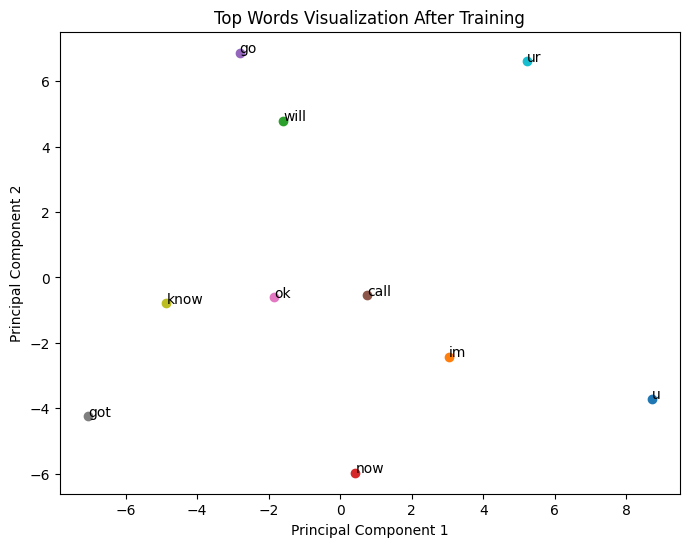

In [ ]:
# prompt: visualize top_words using an appropriate plot using the embeddings after training

# Get the word vectors for the top words after training
top_word_vectors_after_training = [embeddings_after_training[vectorize_layer([word])[0][0]] for word in top_words]

# Apply PCA to reduce the dimensionality to 2
pca = PCA(n_components=2)
reduced_vectors_after_training = pca.fit_transform(top_word_vectors_after_training)

# Create a scatter plot
plt.figure(figsize=(8, 6))
for i, word in enumerate(top_words):
  x = reduced_vectors_after_training[i][0]
  y = reduced_vectors_after_training[i][1]
  plt.scatter(x, y)
  plt.annotate(word, (x, y))

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Top Words Visualization After Training")
plt.show()


### Save the Trained Model

In [ ]:
import torch.jit

# Option 1: Save the model's state dictionary (recommended for continued training or flexible loading)
torch.save(model.state_dict(), 'spam_classifier_state_dict.pth')
print("Model state dictionary saved as 'spam_classifier_state_dict.pth'")

# Option 2: Save the entire model as a TorchScript file (recommended for deployment or inference)
# You might need to provide a dummy input for tracing if your model has conditional logic or loops
# For this simple model, scripting directly should work.
scripted_model = torch.jit.script(model)
scripted_model.save('spam_classifier_scripted.pt')
print("Scripted model saved as 'spam_classifier_scripted.pt'")


Model state dictionary saved as 'spam_classifier_state_dict.pth'
Scripted model saved as 'spam_classifier_scripted.pt'


In [ ]:
# Get vocabulary learned during adapt()
vocab = vectorize_layer.get_vocabulary()

# Save vocabulary
import pickle
with open("vectorizer_vocab.pkl", "wb") as f:
    pickle.dump(vocab, f)

### Load the Saved Model and Do Inference

In [ ]:
import torch
import torch.nn as nn

# Define the SpamClassifier class again, as it's needed to load the state_dict
# This definition should be identical to the one used during training.
class SpamClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim):
        super(SpamClassifier, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, text):
        embedded = self.embedding(text)
        output, (hidden, cell) = self.lstm(embedded)
        final_output = self.fc(hidden[-1, :, :])
        return final_output

# Model parameters (must match the parameters used to create the saved model)
vocab_size = 5000
embedding_dim = 128
hidden_dim = 256
output_dim = 1

# Option 1: Load the model's state dictionary
loaded_model_state_dict = SpamClassifier(vocab_size, embedding_dim, hidden_dim, output_dim)
loaded_model_state_dict.load_state_dict(torch.load('spam_classifier_state_dict.pth'))
loaded_model_state_dict.eval() # Set the model to evaluation mode
print("Model state dictionary loaded successfully!")

# Option 2: Load the entire scripted model
loaded_scripted_model = torch.jit.load('spam_classifier_scripted.pt')
loaded_scripted_model.eval() # Set the model to evaluation mode
print("Scripted model loaded successfully!")


Model state dictionary loaded successfully!
Scripted model loaded successfully!


In [ ]:
new_text = "Thanks for sending the notes at this time."

# 1. Clean the text
cleaned_text = clean_text(new_text)

# 2. Vectorize the text
vectorized_text = vectorize_layer([cleaned_text])

# 3. Convert to PyTorch tensor
input_tensor = torch.tensor(vectorized_text.numpy(), dtype=torch.long)

# 4. Pass the tensor to the model
output = loaded_scripted_model(input_tensor)

print("Model output (logits):")
print(output)

# To get a probability and predicted class (spam/ham):
probability = torch.sigmoid(output).item()
predicted_class = "spam" if probability > 0.5 else "ham"

print(f"\nInput text: '{new_text}'")
print(f"Predicted probability: {probability:.4f}")
print(f"Predicted class: {predicted_class}")


Model output (logits):
tensor([[-1.9701]], grad_fn=<AddmmBackward0>)

Input text: 'Thanks for sending the notes at this time.'
Predicted probability: 0.1224
Predicted class: ham


---

<center>
$END$
</center>

---